# 🧩 Lesson 11 · 子图（独立 State）

> **模块化**：父图生成英文答案，再 `subgraph.invoke` 翻译——子图有独立 `SubState`。

本课你会学到：
- 子图可以有自己的 State schema
- 父节点负责字段映射（进 / 出子图）
- 何时用「独立 State」而不是共享 State

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    subgraph Parent
      S([START]) --> A[generate_answer]
      A --> T[translate_answer]
      T --> E([END])
    end

    subgraph Child["子图 SubState"]
      CS([START]) --> TR[translate_text]
      TR --> CE([END])
    end

    T -.->|invoke input_text| CS
    CE -.->|translated_text| T


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S,CS input
    class A,T,TR llm
    class E,CE output
```

**要点：** 隔离 State 时，父节点负责映射字段进/出子图。



# Imports


In [1]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv



C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


In [2]:
load_dotenv()

True

# 子图 State

独立 `SubState`：只关心 `input_text` → `translated_text`。


In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

subgraph_llm = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)




# 子图 Node — translate_text


In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

# 编译子图


In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

# 父图 State

父节点负责把字段映射进/出子图。


In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [8]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

parent_llm = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)

# 父图 Node — generate_answer


In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

# 父图 Node — translate_answer

内部 `subgraph.invoke(...)`，再写回父 State。


In [10]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

# 编译父图


In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

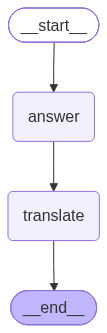

In [12]:
graph = parent_builder.compile()

graph

In [13]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics (also called quantum mechanics or quantum theory) is the branch of physics that describes how the universe works at the smallest scales—at the level of atoms and subatomic particles (like electrons, photons, and quarks).\n\nHere’s a clear breakdown of what makes it special and how it differs from the physics we see in everyday life.\n\n---\n\n### 1. The Core Idea: Energy Comes in Chunks\nIn our everyday world, we think of things as continuous. For example, you can speed up a car smoothly from 0 to 60 mph. In the quantum world, however, certain properties are **quantized**, meaning they come in discrete, indivisible packets called "quanta."\n\n- **Analogy:** Think of a ramp versus a staircase. On a ramp (classical physics), you can stand at any height. On a staircase (quantum physics), you can only stand on specific steps. An electron in an atom can only have specific energy levels, not any value in between.\n\n---\